# Notebook for analysisg

In [1]:
# run the import and install packages.py file 
%run install_packages.py

MIRSI Simulations - Package Dependency Checker

Checking for required packages...
✓ numpy is already installed
✓ astropy is already installed
✓ matplotlib is already installed
✓ photutils is already installed
✓ scipy is already installed

✓ All required packages are already installed!

Setup complete! You can now run the MIRSI simulations.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry 


## DATA FROM 12-27-25   

### Zenith

Processing 1500 FITS files from ./data/251227/zenith_1
Loaded 1500 FITS files from ./data/251227/zenith_1
Processing 1500 FITS files from ./data/251227/zenith_2
Loaded 1500 FITS files from ./data/251227/zenith_2
Processing 1500 FITS files from ./data/251227/zenith_3
Loaded 1500 FITS files from ./data/251227/zenith_3


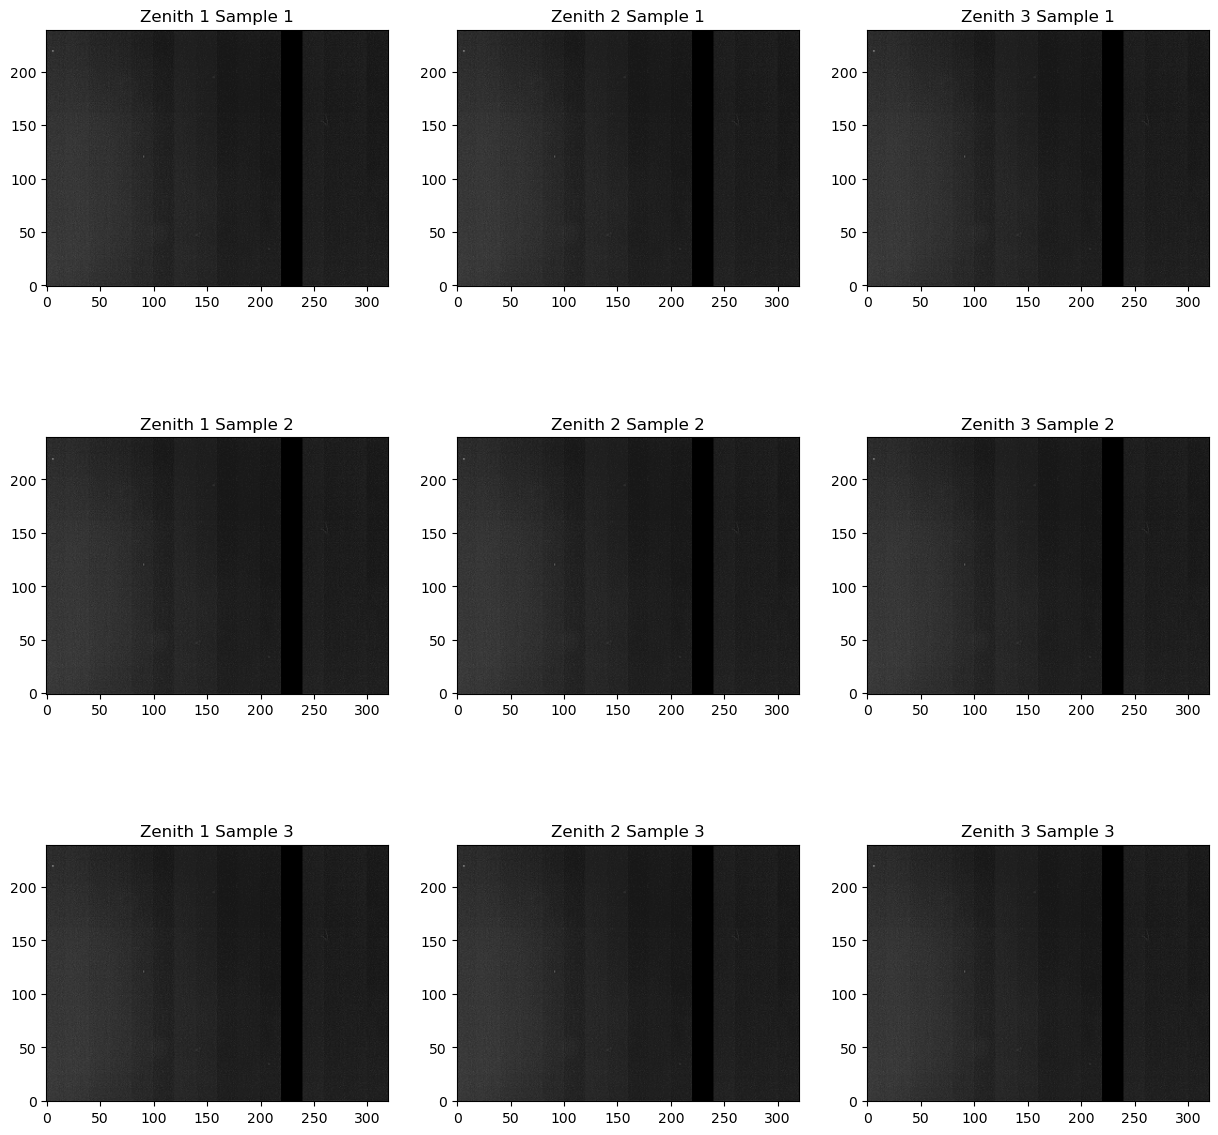

In [3]:
# Read in the data from the fits file 
from test_analysis import read_in_fits
zenith_1_data = read_in_fits('./data/251227/zenith_1')
zenith_2_data = read_in_fits('./data/251227/zenith_2')
zenith_3_data = read_in_fits('./data/251227/zenith_3')
# display three random images from each to make sure it loaded in correctly
test_fig, test_axs = plt.subplots(3,3, figsize=(15,15))
for i, data in enumerate([zenith_1_data, zenith_2_data, zenith_3_data]):
    for j in range(3):
        test_axs[j,i].imshow(data[np.random.randint(0, data.shape[0])], cmap='gray', origin='lower')
        test_axs[j,i].set_title(f'Zenith {i+1} Sample {j+1}')
plt.show()


Perform aperture photometry in the selected region

In [4]:
from test_analysis import preliminary_analysis
region = (30,80,15)  # Example region (y, x, radius)
TRIM_FRAMES = (149, -1)

In [5]:
import numpy as np
from photutils.aperture import CircularAperture, CircularAnnulus

def extract_sky_timeseries(exposures, region, trim=None, annulus=None, statistic="mean"):
    """
    Build a 1D time series x[t] = sky level estimator from a fixed aperture (and optional annulus).

    Parameters
    ----------
    exposures : (n, H, W) ndarray
    region : (y, x, r)
        aperture center and radius in pixels
    trim : (i0, i1) or None
        slice frames: exposures[i0:i1]
    annulus : (r_in, r_out) or None
        if provided, compute annulus background and subtract it from aperture mean/sum
    statistic : {'mean','median','sum'}
        how to summarize pixels inside the aperture

    Returns
    -------
    out : dict with keys:
        'x_ap' : aperture statistic time series (background-subtracted if annulus given)
        'x_ann' : annulus statistic time series (if annulus given)
        'n_pix_ap', 'n_pix_ann'
    """
    if trim is not None:
        exposures = exposures[trim[0]:trim[1]]

    y, x, r = region
    pos = (x, y)

    ap = CircularAperture(pos, r=r)#
    ap_mask = ap.to_mask(method="center")
    # Fix: to_mask() returns a single mask, not a list - remove [0]
    ap_mask = ap_mask.to_image(exposures.shape[1:]).astype(bool)
    n_pix_ap = ap_mask.sum()

    if annulus is not None:
        r_in, r_out = annulus
        an = CircularAnnulus(pos, r_in=r_in, r_out=r_out)
        an_mask = an.to_mask(method="center")
        # Fix: same here - remove [0]
        an_mask = an_mask.to_image(exposures.shape[1:]).astype(bool)
        n_pix_ann = an_mask.sum()
    else:
        an_mask = None
        n_pix_ann = 0

    x_ap = np.empty(exposures.shape[0], dtype=float)
    x_ann = np.empty(exposures.shape[0], dtype=float) if an_mask is not None else None

    for i, frame in enumerate(exposures):
        ap_vals = frame[ap_mask]

        if statistic == "mean":
            ap_stat = np.mean(ap_vals)
        elif statistic == "median":
            ap_stat = np.median(ap_vals)
        elif statistic == "sum":
            ap_stat = np.sum(ap_vals)
        else:
            raise ValueError("statistic must be 'mean', 'median', or 'sum'")

        if an_mask is not None:
            ann_vals = frame[an_mask]
            # robust background: median is usually best
            ann_stat = np.median(ann_vals)
            x_ann[i] = ann_stat

            # subtract background in consistent units:
            # if 'sum', subtract (background * n_pix_ap); if mean/median, subtract background directly
            if statistic == "sum":
                ap_stat = ap_stat - ann_stat * n_pix_ap
            else:
                ap_stat = ap_stat - ann_stat

        x_ap[i] = ap_stat

    out = {"x_ap": x_ap, "n_pix_ap": n_pix_ap}
    if x_ann is not None:
        out.update({"x_ann": x_ann, "n_pix_ann": n_pix_ann})
    return out


In [6]:
def variance_vs_frequency_series(x, coadds_list, frame_dt_s, ddof=1):
    """
    For each coadds, average x into blocks and compute Var(block_means).
    """
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var": []}

    for n in coadds_list:
        Ntrim = (len(x) // n) * n
        if Ntrim < 2*n:
            continue
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)   # mean keeps units consistent
        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var"].append(np.var(xb, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [7]:
def variance_vs_frequency_chop_proxy(x, coadds_list, frame_dt_s, ddof=1):
    """
    For each coadds, compute block means then take successive differences and compute Var(diffs).

    
    """
    # Initialize output dictionary
    out = {"coadds": [], "f_eff_hz": [], "n_blocks": [], "var_diff": []}

    # Loop over each coadds value
    for n in coadds_list:
        # Trim x to a multiple of n
        Ntrim = (len(x) // n) * n
        if Ntrim < 3*n:   # need at least 3 blocks to get >=2 diffs
            continue
        # Groups n consecutive frames and computes their mean
        xb = x[:Ntrim].reshape(-1, n).mean(axis=1)

        # Computes successive differences (i.e. A - B subtraction)
        d = np.diff(xb)

        out["coadds"].append(n)
        out["f_eff_hz"].append(1.0 / (frame_dt_s * n))
        out["n_blocks"].append(len(xb))
        out["var_diff"].append(np.var(d, ddof=ddof))

    return {k: np.array(v) for k, v in out.items()}


In [8]:
z2 = extract_sky_timeseries(zenith_2_data, region, trim=None, annulus=None, statistic="mean")
z3 = extract_sky_timeseries(zenith_3_data, region, trim=None, annulus=None, statistic="mean")

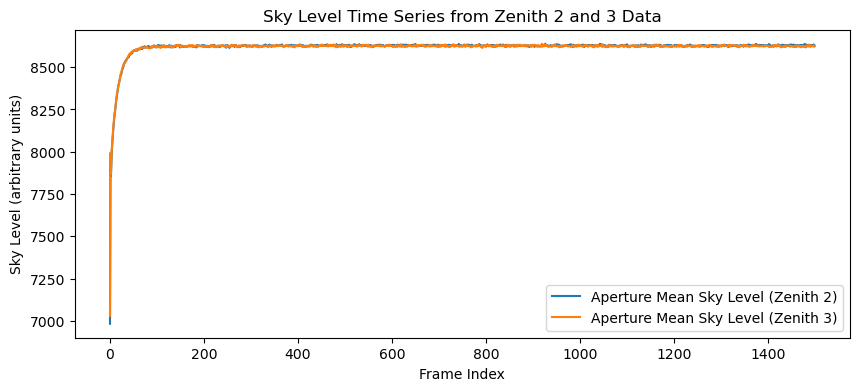

In [9]:
# First plot the non-trimmed time series
plt.figure(figsize=(10,4))
plt.plot(z2['x_ap'], label='Aperture Mean Sky Level (Zenith 2)')
plt.plot(z3['x_ap'], label='Aperture Mean Sky Level (Zenith 3)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 2 and 3 Data')
plt.legend()
plt.show()

These frames are strange since the counts initially need to go up...

In [10]:
z2 = extract_sky_timeseries(zenith_2_data, region, trim=TRIM_FRAMES, annulus=None, statistic="mean")
z3 = extract_sky_timeseries(zenith_3_data, region, trim=TRIM_FRAMES, annulus=None, statistic="mean")

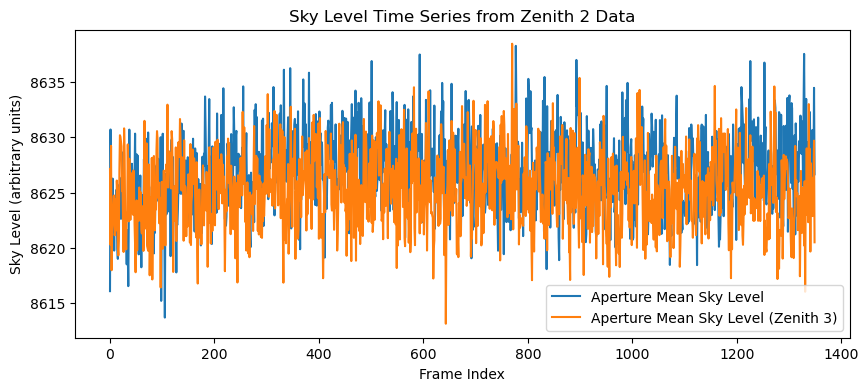

In [11]:
plt.figure(figsize=(10,4))
plt.plot(z2['x_ap'], label='Aperture Mean Sky Level')
plt.plot(z3['x_ap'], label='Aperture Mean Sky Level (Zenith 3)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 2 Data')
plt.legend()
plt.show()

In [29]:
from scipy.ndimage import uniform_filter1d

First just try plotting the values and looking at the scatter we'll just bin the data and see


In [30]:
#  

In [34]:
# binned twice 
coadds_2 = uniform_filter1d(z2['x_ap'], size=2, mode='nearest')[::2]
coadds_3 = uniform_filter1d(z2['x_ap'], size=3, mode='nearest')[::3]
coadds_5 = uniform_filter1d(z2['x_ap'], size=5,
    mode='nearest')[::5]
coadds_10 = uniform_filter1d(z2['x_ap'], size=10,
    mode='nearest')[::10]
coadds_20 = uniform_filter1d(z2['x_ap'], size=20,
    mode='nearest')[::20]
coadds_50 = uniform_filter1d(z2['x_ap'], size=50,
    mode='nearest')[::50]   
coadds_100 = uniform_filter1d(z2['x_ap'], size=100,
    mode='nearest')[::100]
caoadds_200 = uniform_filter1d(z2['x_ap'], size=200,
    mode='nearest')[::200]

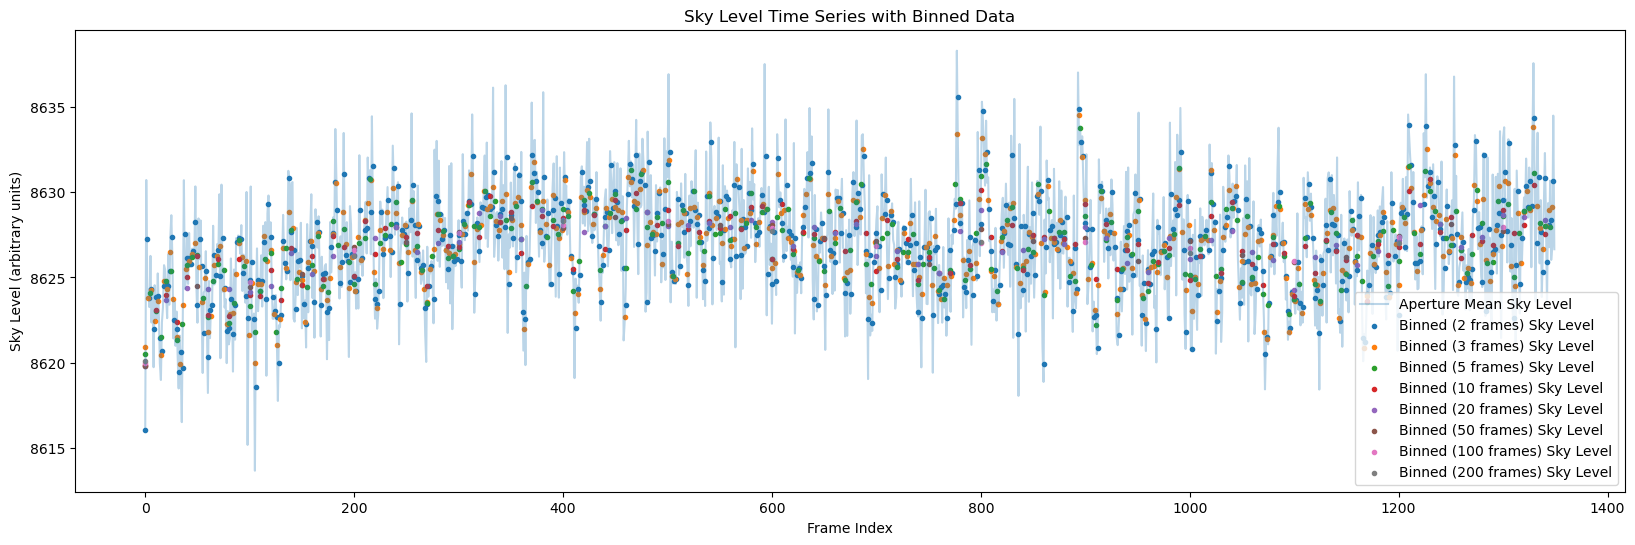

In [36]:
#  overplot the binned data
plt.figure(figsize=(20, 6))
plt.plot(z2['x_ap'], label='Aperture Mean Sky Level', alpha = 0.3)
plt.scatter(range(0, len(z2['x_ap']), 2), coadds_2, label='Binned (2 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 3), coadds_3, label='Binned (3 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 5), coadds_5, label='Binned (5 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 10), coadds_10, label='Binned (10 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 20), coadds_20, label='Binned (20 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 50), coadds_50, label='Binned (50 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 100), coadds_100, label='Binned (100 frames) Sky Level', marker='.')
plt.scatter(range(0, len(z2['x_ap']), 200), caoadds_200, label='Binned (200 frames) Sky Level', marker='.')

plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series with Binned Data')
plt.legend()
plt.show()

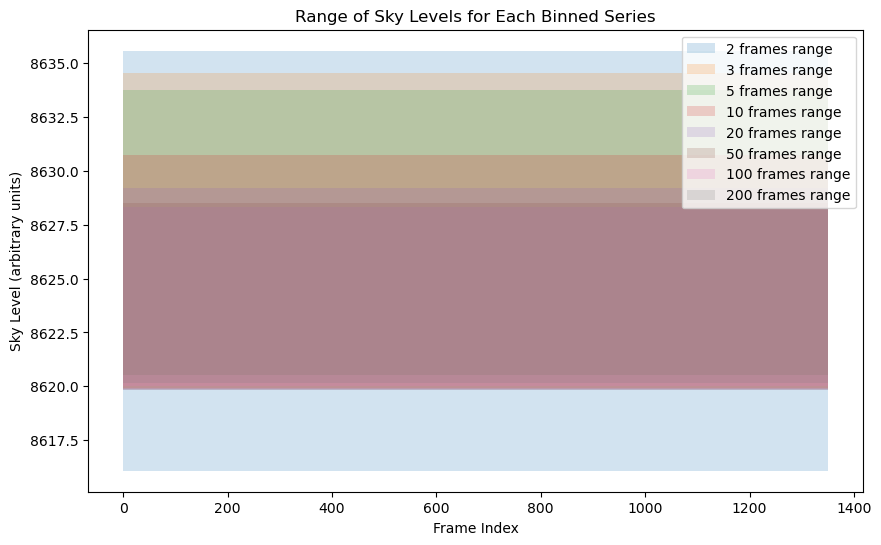

In [ ]:
# plot and fill in the 1 sigma ranges for each binned series

plt.figure(figsize=(10, 6))
for label, (bmin, bmax) in binned_stats.items():
    plt.fill_betweenx([bmin, bmax], 0, len(z2['x_ap']), alpha=0.2, label=f'{label} range')      
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Range of Sky Levels for Each Binned Series')
plt.legend()
plt.show()

In [23]:
# Make a list of integers for coadds 5 - 100
cadds_list = np.arange(5, 251)
#cadds_list = [6, 7, 8,9, 10,20,30, 40, 50, 60, 70, 80, 90, 100]

v2_series = variance_vs_frequency_series(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113)
v2_chop = variance_vs_frequency_chop_proxy(
    z2['x_ap'], cadds_list, frame_dt_s=0.0113)

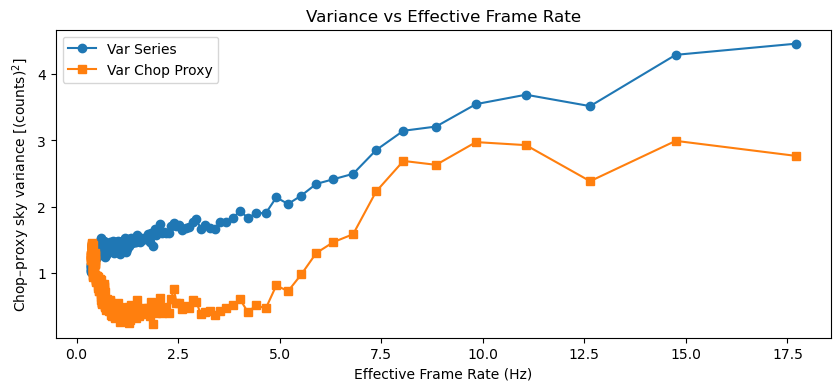

In [24]:
plt.figure(figsize=(10,4))
plt.plot(v2_series['f_eff_hz'], v2_series['var'],
         marker='o', label='Var Series')
plt.plot(v2_chop['f_eff_hz'], v2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")

plt.title('Variance vs Effective Frame Rate')
plt.legend()
plt.show()

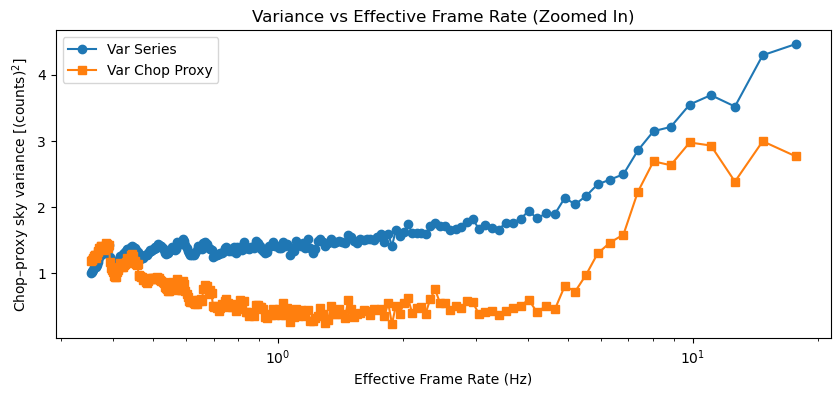

In [38]:
# Zoom in on the plot 
plt.figure(figsize=(10,4))
plt.plot(v2_series['f_eff_hz'], v2_series['var'],
         marker='o', label='Var Series')
plt.plot(v2_chop['f_eff_hz'], v2_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.xlabel('Effective Frame Rate (Hz)')
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
#plt.xlim(0, 7)  # Zoom in on x-axis
plt.xscale('log')
plt.title('Variance vs Effective Frame Rate (Zoomed In)')
plt.legend()

When interpreting sky-noise measurements as a function of chop frequency, it is important to distinguish between the variance of an individual chop difference and the residual noise obtained over a fixed total observing time. In the fast-chopping limit, subtraction effectively removes slowly varying atmospheric emission; however, the differenced signal remains dominated by uncorrelated photon and detector noise, which cannot be subtracted and contributes a variance floor of approximately twice the single-sample white-noise variance. Conversely, at slower chop frequencies the longer dwell time in each chop position reduces white noise through temporal averaging, but allows the atmospheric background to evolve between chop states, introducing correlated sky noise into the differenced signal. In regimes where the sky remains stable on these timescales, the reduction in white noise can outweigh the increase in atmospheric fluctuations, leading to a lower variance per individual chop difference at slower chop frequencies. 



This behavior does not imply that slow chopping is intrinsically optimal; rather, it reflects that the measured quantity is the variance per chop, not the noise achieved after averaging many chops over a fixed integration time. The optimal chop frequency is therefore determined by the balance between white-noise averaging and correlated sky variability when normalized to a constant total observing time, rather than by the variance of a single chop difference alone.

#### Take a look at the "long term" behavior 

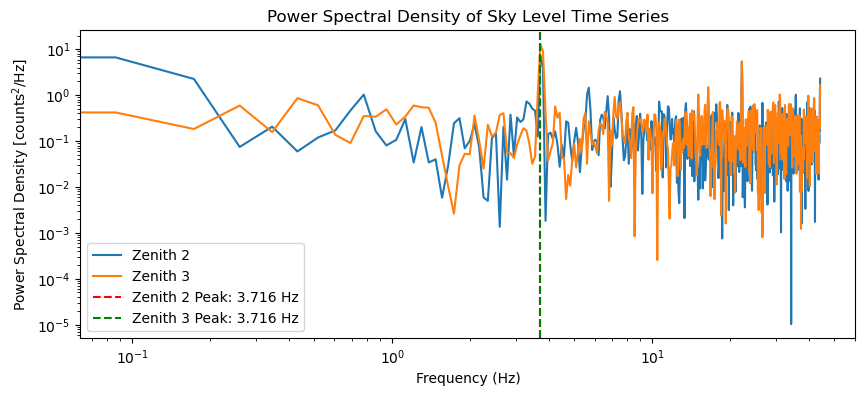

In [14]:
# Get a PSD of the time series
from scipy.signal import welch
f2, Pxx2 = welch(z2['x_ap'], fs=1/0.0113, nperseg=1024)

# Other time series 
f3, Pxx3 = welch(z3['x_ap'], fs=1/0.0113, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f2, Pxx2, label='Zenith 2')
ax.loglog(f3, Pxx3, label='Zenith 3')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series')

# Find the maximum value 
max2_index = np.argmax(Pxx2)
max2_frequency = f2[max2_index]
max2_value = Pxx2[max2_index]

max3_index = np.argmax(Pxx3)
max3_frequency = f3[max3_index]
max3_value = Pxx3[max3_index]


plt.axvline(max2_frequency, color='r', linestyle='--', label=f'Zenith 2 Peak: {max2_frequency:.3f} Hz')
plt.axvline(max3_frequency, color='g', linestyle='--', label=f'Zenith 3 Peak: {max3_frequency:.3f} Hz')
plt.legend()
plt.show()

## Zenith Short Exposures 

Here we test the expsoures where we have "shortened exposure time". 
We may get more impacts from things like dark current, but still should be useful for trying to test out correlated sky. 

In [15]:
# Import the data 
zenith_SE_data = read_in_fits('./data/251227/zenith_4_se')
z4_SE = extract_sky_timeseries(zenith_SE_data, region, trim=None, annulus=None, statistic="mean")


Processing 1500 FITS files from ./data/251227/zenith_4_se
Loaded 1500 FITS files from ./data/251227/zenith_4_se


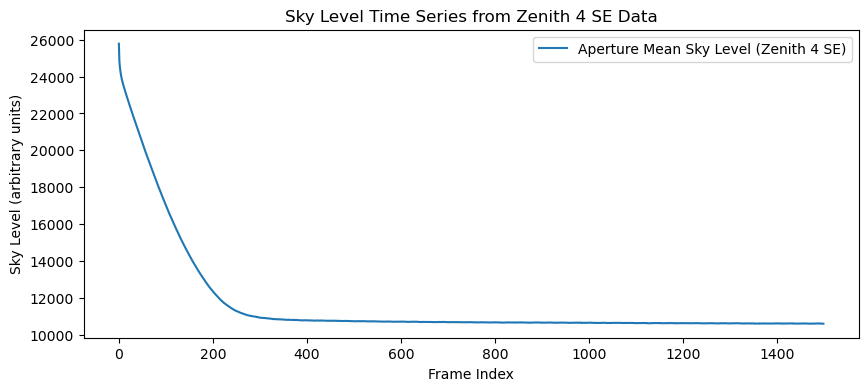

In [16]:
# plot the time series
plt.figure(figsize=(10,4))
plt.plot(z4_SE['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 4 SE Data')
plt.legend()
plt.show()

it looks like the "ramp down" happens faster in this series 


In [17]:
# Reload int ghe datea taking from frame number ~400 to the end 
z4_SE_clipped = extract_sky_timeseries(zenith_SE_data, region, trim=(400, None), annulus=None, statistic="mean")

# pick new region (larger radius)
# should be double the previous area (sqrt 2 times the radius)
region2 = (30,80,30)

s4_SE_clipped_large = extract_sky_timeseries(zenith_SE_data, region2, trim=(400, None), annulus=None, statistic="mean")

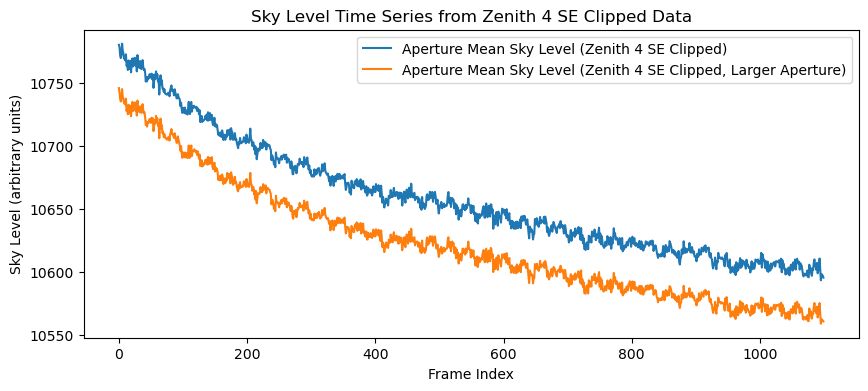

In [18]:
plt.figure(figsize=(10,4))
plt.plot(z4_SE_clipped['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE Clipped)')
plt.plot(s4_SE_clipped_large['x_ap'], label='Aperture Mean Sky Level (Zenith 4 SE Clipped, Larger Aperture)')
plt.xlabel('Frame Index')
plt.ylabel('Sky Level (arbitrary units)')
plt.title('Sky Level Time Series from Zenith 4 SE Clipped Data')
plt.legend()
plt.show()

Still a significant downturn in counts...

In [19]:
# increase the coadds list for this data set
cadds_list = np.arange(10, 301)
z4_series = variance_vs_frequency_series(
    z4_SE_clipped['x_ap'], cadds_list, frame_dt_s=0.0053)
z4_chop = variance_vs_frequency_chop_proxy(
    z4_SE_clipped['x_ap'], cadds_list, frame_dt_s=0.0053)

z4_series_large = variance_vs_frequency_series(
    s4_SE_clipped_large['x_ap'], cadds_list, frame_dt_s=0.0053)
z4_chop_large = variance_vs_frequency_chop_proxy(
    s4_SE_clipped_large['x_ap'], cadds_list, frame_dt_s=0.0053)

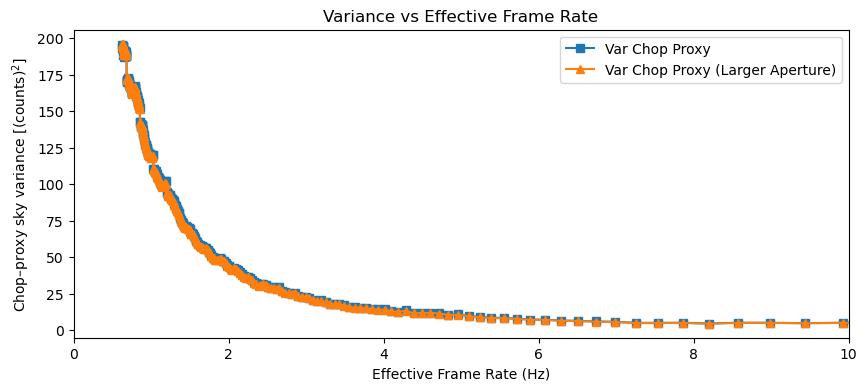

In [20]:
# plot the results 
plt.figure(figsize=(10,4))
#plt.plot(z4_series['f_eff_hz'], z4_series['var'],
#         marker='o', label='Var Series')
plt.plot(z4_chop['f_eff_hz'], z4_chop['var_diff']/2,
         marker='s', label='Var Chop Proxy')
plt.plot(z4_chop_large['f_eff_hz'], z4_chop_large['var_diff']/2,
         marker='^', label='Var Chop Proxy (Larger Aperture)')
plt.xlabel('Effective Frame Rate (Hz)')
plt.xlim(0, 10)
plt.ylabel(r"Chop–proxy sky variance [$({\rm counts})^2$]")
plt.title('Variance vs Effective Frame Rate')
plt.legend()
plt.show()


I think this is 1/f noise - if it were sky noise, the variance would scale with Area (not sure which direction though)

Get the PSD of the  

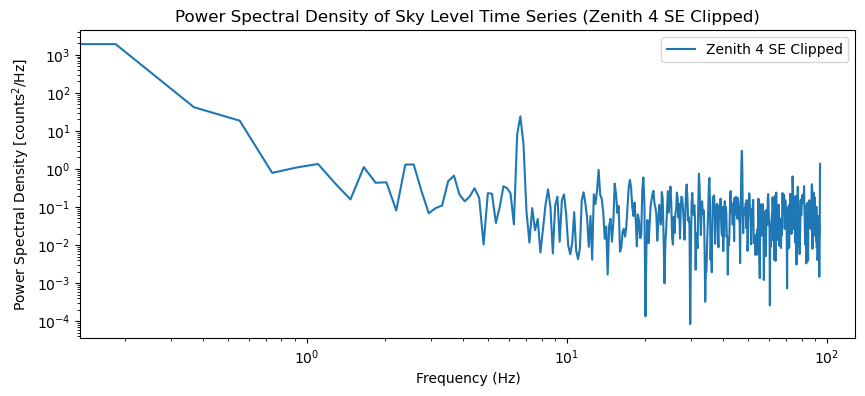

In [21]:
f4, Pxx4 = welch(z4_SE_clipped['x_ap'], fs=1/0.0053, nperseg=1024)
fig, ax = plt.subplots(figsize=(10,4))
ax.loglog(f4, Pxx4, label='Zenith 4 SE Clipped')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power Spectral Density [counts$^2$/Hz]')
ax.set_title('Power Spectral Density of Sky Level Time Series (Zenith 4 SE Clipped)')
plt.legend()
plt.show()

# High Airmass

We repeat the same analysis as above, but this time with higher airmass values. 

NameError: name 'zenith_1_phot' is not defined

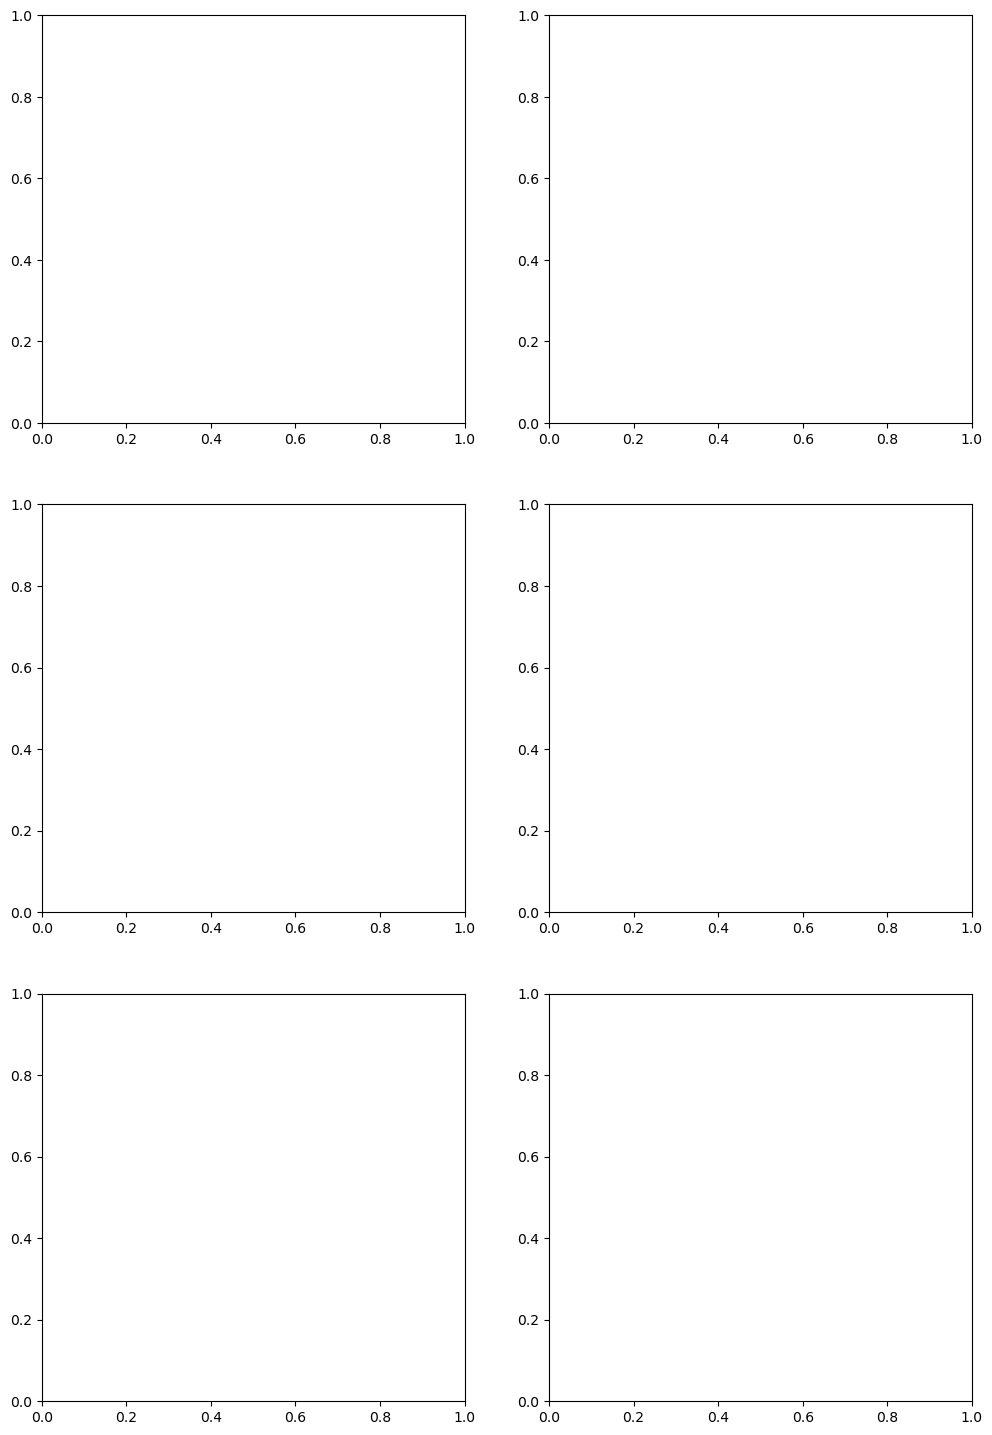

In [22]:
# Plot the region and photometry results 
apertures = CircularAperture((region[1], region[0]), r=region[2])
fig, ax = plt.subplots(3,2, figsize=(12,18))
for i, (data, phot, title) in enumerate(zip([zenith_1_data, zenith_2_data, zenith_3_data],
                                           [zenith_1_phot, zenith_2_phot, zenith_3_phot],
                                           ['Zenith 1', 'Zenith 2', 'Zenith 3'])):
    ax[i,0].imshow(data[0], cmap='gray', origin='lower')
    apertures.plot(ax[i,0], color='red', lw=2)
    ax[i,0].set_title(f'{title} - Sample Image with Aperture')
    
    ax[i,1].plot(phot['aperture_sum'], marker='o')
    ax[i,1].set_title(f'{title} - Aperture Photometry Over Time')
    ax[i,1].set_xlabel('Frame index')
    ax[i,1].set_ylabel('Aperture Sum')
    # Twin y to plot variance 
    ax2 = ax[i,1].twinx()
    ax2.plot(phot['aperture_var'], marker='x', color='blue')
    ax2.set_ylabel('Aperture Variance', color='blue')
plt.tight_layout()
plt.show()


I think something went wrong with the first exposure sequence. The other two look okay though - very interesting that there is an increase in the signal (we saw a decrease the last time) 

Cut the first 150 frames out of the sequence    

In [ ]:
# Coadd the frames and see what you end up with 
import numpy as np

def coadd_exposures(exposure_sequence, coadds, mode="average", dtype=np.float32):
    """
    Coadd frames in non-overlapping blocks of size `coadds`.
    Returns array (n_blocks, H, W).
    """
    if coadds < 1:
        raise ValueError("coadds must be >= 1")

    n, H, W = exposure_sequence.shape
    n_use = (n // coadds) * coadds
    if n_use < coadds:
        raise ValueError(f"Not enough frames ({n}) for coadds={coadds}")

    blocks = exposure_sequence[:n_use].reshape(n_use // coadds, coadds, H, W)

    if mode == "average":
        out = blocks.mean(axis=1, dtype=np.float64)
    elif mode == "sum":
        out = blocks.sum(axis=1, dtype=np.float64)
    elif mode == "sum_normalized":
        out = blocks.sum(axis=1, dtype=np.float64) / coadds
    else:
        raise ValueError("mode must be 'average', 'sum', or 'sum_normalized'")

    return out.astype(dtype, copy=False)


def _compute_variances_from_series(x, use_differences=True, ddof=1):
    """
    Returns (var_series, var_diff, n_series, n_diff)
    """
    x = np.asarray(x, dtype=float)
    v_series = np.var(x, ddof=ddof)
    n_series = x.size

    if use_differences:
        dx = np.diff(x)
        v_diff = np.var(dx, ddof=ddof)
        n_diff = dx.size
    else:
        v_diff = np.nan
        n_diff = 0

    return v_series, v_diff, n_series, n_diff


# -------------------------
# A) FIXED TOTAL RAW FRAMES
# -------------------------
def variance_vs_coadds_fixed_total_frames(
    exposure_sequence,
    coadds_list,
    stat_fn,
    n_frames_total=None,
    mode="average",
    use_differences=True,
    ddof=1,
):
    """
    Option A: Fix the total number of raw frames used for every coadds
    (fixed time baseline). The number of coadded samples varies with coadds.

    Parameters
    ----------
    n_frames_total : int or None
        If None, uses all frames in exposure_sequence. If provided, uses the first
        n_frames_total frames (trimmed down further to a multiple of coadds).

    Returns
    -------
    dict with arrays:
      coadds, n_frames_used, n_blocks_used, n_series, n_diff, var_series, var_diff
    """
    n_all = exposure_sequence.shape[0]
    if n_frames_total is None:
        n_frames_total = n_all
    n_frames_total = min(n_frames_total, n_all)

    out = {k: [] for k in [
        "coadds", "n_frames_used", "n_blocks_used", "n_series", "n_diff", "var_series", "var_diff"
    ]}

    base = exposure_sequence[:n_frames_total]

    for c in coadds_list:
        n_use = (base.shape[0] // c) * c
        if n_use < 2 * c:
            # need at least 2 coadded points if using differences
            continue

        seq = base[:n_use]
        coadded = coadd_exposures(seq, coadds=c, mode=mode)

        x = np.array([stat_fn(im) for im in coadded], dtype=float)
        v_series, v_diff, n_series, n_diff = _compute_variances_from_series(
            x, use_differences=use_differences, ddof=ddof
        )

        out["coadds"].append(c)
        out["n_frames_used"].append(n_use)
        out["n_blocks_used"].append(coadded.shape[0])
        out["n_series"].append(n_series)
        out["n_diff"].append(n_diff)
        out["var_series"].append(v_series)
        out["var_diff"].append(v_diff)

    return {k: np.array(v) for k, v in out.items()}


# ----------------------------
# B) FIXED # COADDED SAMPLES
# ----------------------------
def variance_vs_coadds_fixed_n_blocks(
    exposure_sequence,
    coadds_list,
    stat_fn,
    n_blocks=200,
    mode="average",
    use_differences=True,
    ddof=1,
):
    """
    Option B: Fix the number of coadded samples used in the variance estimate
    (constant estimator sample size). Total raw frames used grows with coadds.

    Uses exactly n_blocks * coadds frames when possible; otherwise uses the maximum
    full blocks available and reports n_blocks_used.

    Returns
    -------
    dict with arrays:
      coadds, n_frames_used, n_blocks_used, n_series, n_diff, var_series, var_diff
    """
    n_all = exposure_sequence.shape[0]
    out = {k: [] for k in [
        "coadds", "n_frames_used", "n_blocks_used", "n_series", "n_diff", "var_series", "var_diff"
    ]}

    for c in coadds_list:
        frames_needed = n_blocks * c

        if n_all >= frames_needed:
            n_use = frames_needed
            nb_used = n_blocks
        else:
            nb_used = n_all // c
            n_use = nb_used * c

        if nb_used < 2:
            continue

        seq = exposure_sequence[:n_use]
        coadded = coadd_exposures(seq, coadds=c, mode=mode)

        x = np.array([stat_fn(im) for im in coadded], dtype=float)
        v_series, v_diff, n_series, n_diff = _compute_variances_from_series(
            x, use_differences=use_differences, ddof=ddof
        )

        out["coadds"].append(c)
        out["n_frames_used"].append(n_use)
        out["n_blocks_used"].append(nb_used)
        out["n_series"].append(n_series)
        out["n_diff"].append(n_diff)
        out["var_series"].append(v_series)
        out["var_diff"].append(v_diff)

    return {k: np.array(v) for k, v in out.items()}


# -------------------------
# Convenience: effective Hz
# -------------------------
def add_effective_frequency(results, frame_rate_hz):
    """
    Adds f_eff = frame_rate_hz / coadds to a results dict (returns a copy).
    """
    out = dict(results)
    out["f_eff_hz"] = frame_rate_hz / out["coadds"]
    return out


In [ ]:
from photutils.aperture import CircularAperture, aperture_photometry

ap = CircularAperture((region[1], region[0]), r=region[2])
ap_area = ap.area

def stat_fn(image):
    tbl = aperture_photometry(image, ap)
    return float(tbl["aperture_sum"][0] / ap_area)  # mean in aperture


In [ ]:
coadds_list = [1, 2, 3, 5, 6,  7, 8,9,10]
frame_rate_hz = CHAR_FREQ = 1/0.0113

res_A = variance_vs_coadds_fixed_total_frames(
    zenith_2_data,
    coadds_list,
    stat_fn,
    n_frames_total=1350,   # or None for all
    mode="average",
    use_differences=True
)

res_B = variance_vs_coadds_fixed_n_blocks(
    zenith_2_data,
    coadds_list,
    stat_fn,
    n_blocks=100,
    mode="average",
    use_differences=True
)

res_A = add_effective_frequency(res_A, frame_rate_hz)
res_B = add_effective_frequency(res_B, frame_rate_hz)


In [ ]:
res_A,

({'coadds': array([ 1,  2,  3,  5,  6,  7,  8,  9, 10]),
  'n_frames_used': array([1350, 1350, 1350, 1350, 1350, 1344, 1344, 1350, 1350]),
  'n_blocks_used': array([1350,  675,  450,  270,  225,  192,  168,  150,  135]),
  'n_series': array([1350,  675,  450,  270,  225,  192,  168,  150,  135]),
  'n_diff': array([1349,  674,  449,  269,  224,  191,  167,  149,  134]),
  'var_series': array([5246.83358773, 4891.79672708, 4814.21951539, 4681.45542412,
         4624.75927661, 4587.51009126, 4530.53452295, 4457.88353846,
         4402.57824433]),
  'var_diff': array([ 740.52581971,  345.79056516,  458.39437398,  686.05154135,
          808.01157821,  935.10945007, 1057.91152242, 1175.70656794,
         1293.94452006]),
  'f_eff_hz': array([88.49557522, 44.24778761, 29.49852507, 17.69911504, 14.74926254,
         12.64222503, 11.0619469 ,  9.83284169,  8.84955752])},)

In [ ]:
res_B

{'coadds': array([ 1,  2,  3,  5,  6,  7,  8,  9, 10]),
 'n_frames_used': array([ 100,  200,  300,  500,  600,  700,  800,  900, 1000]),
 'n_blocks_used': array([100, 100, 100, 100, 100, 100, 100, 100, 100]),
 'n_series': array([100, 100, 100, 100, 100, 100, 100, 100, 100]),
 'n_diff': array([99, 99, 99, 99, 99, 99, 99, 99, 99]),
 'var_series': array([54290.96264395, 29146.20356   , 20076.503835  , 12206.61359498,
        10156.15163618,  8662.31530302,  7524.98161105,  6633.81087292,
         5912.48422243]),
 'var_diff': array([9712.02159153, 2203.10343286, 1985.91475335, 1815.46172027,
        1790.6728823 , 1776.08266825, 1764.10601208, 1754.81951428,
        1741.20953533]),
 'f_eff_hz': array([88.49557522, 44.24778761, 29.49852507, 17.69911504, 14.74926254,
        12.64222503, 11.0619469 ,  9.83284169,  8.84955752])}

Text(0.5, 1.0, 'Fixed Total Raw Frames')

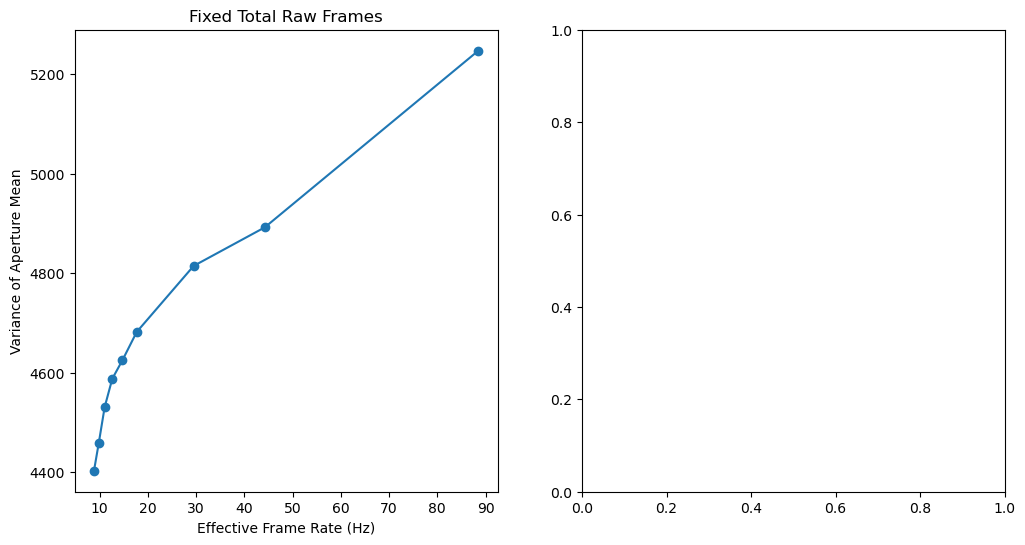

In [ ]:
# plot the f_eff_hz vs the variance results
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[0].plot(res_A['f_eff_hz'], res_A['var_series'],
            marker='o', label='Var Series')
ax[0].set_xlabel('Effective Frame Rate (Hz)')
ax[0].set_ylabel('Variance of Aperture Mean')
ax[0].set_title('Fixed Total Raw Frames')   

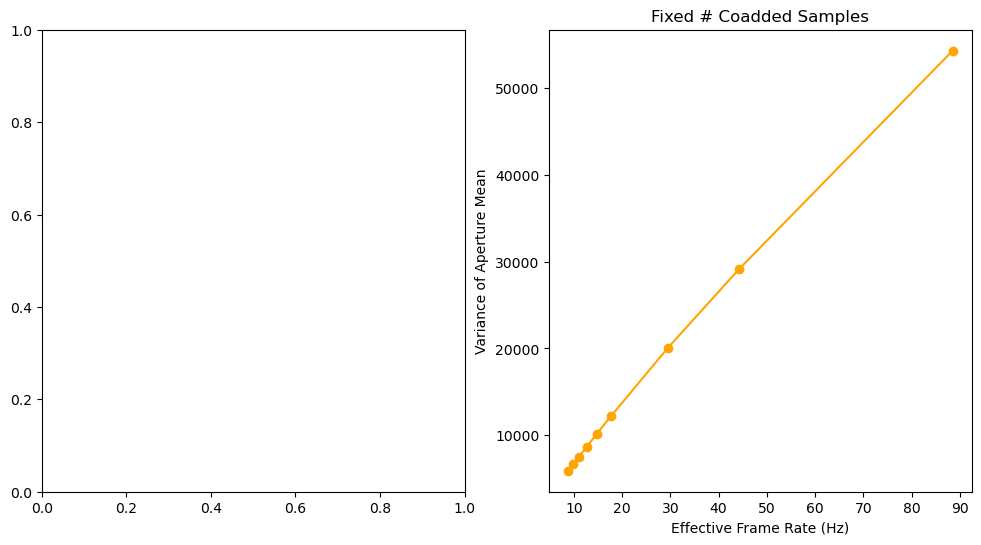

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,6))
ax[1].plot(res_B['f_eff_hz'], res_B['var_series'],
            marker='o', label='Var Series', color='orange')
ax[1].set_xlabel('Effective Frame Rate (Hz)')
ax[1].set_ylabel('Variance of Aperture Mean')
ax[1].set_title('Fixed # Coadded Samples')
plt.show()